### No. of Tourist Arrival by Month

Questions :: Is there a statistically significant difference in monthly tourist arrivals in Nepal between the Pre-COVID period (2017–2019) and the Post-COVID recovery period (2023–2025)?

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import math
import numpy as np
df = pd.read_excel('/content/Current-macroeconomic-situation-Tables-Based-on-Six-Month-data-of-2082.83.xlsx',sheet_name='27.Tourist Arrival ', header=None)
df


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Table 27,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,No. of Tourist Arrival by Month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Year,2005.0,2006.0,2007.0,2008.0,2009.0,2010.0,2011,2012.0,...,2017.0,2018.0,2019.0,2020.0,2021.0,2022.0,2023.0,2024R,2025R,2026P
3,NaN,Month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Jan,25477.0,28769.0,33192.0,36913.0,29278.0,33645.0,42622,52501.0,...,62632.0,73187.0,81273.0,79702.0,8874.0,16975.0,55074.0,79100,79991,92573
5,NaN,Feb,20338.0,25728.0,39934.0,46675.0,40617.0,49264.0,56339,66459.0,...,84061.0,89507.0,102423.0,98190.0,9146.0,19766.0,73255.0,97426,96880,NaN
6,NaN,Mar,29875.0,36873.0,54722.0,58735.0,49567.0,63058.0,67565,89151.0,...,106291.0,124686.0,127351.0,42776.0,14977.0,42006.0,99426.0,128167,121687,NaN
7,NaN,Apr,23414.0,21983.0,40942.0,38475.0,43337.0,45509.0,59751,69796.0,...,88591.0,98650.0,109399.0,14.0,22450.0,61589.0,98773.0,111376,116490,NaN
8,NaN,May,25541.0,22870.0,35854.0,30410.0,30037.0,32542.0,46202,50317.0,...,62773.0,68825.0,78329.0,31.0,1468.0,53608.0,77703.0,90211,86216,NaN
9,NaN,Jun,22608.0,26210.0,31316.0,24349.0,31749.0,33263.0,46115,53630.0,...,55956.0,65159.0,74883.0,102.0,1143.0,46957.0,72250.0,76736,76425,NaN


In [58]:
months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']

clean = pd.DataFrame({
    'Month' : months,
    'Y2017' : df.iloc[4:16, 14].astype(float).values,
    'Y2018' : df.iloc[4:16, 15].astype(float).values,
    'Y2019' : df.iloc[4:16, 16].astype(float).values,
    'Y2023' : df.iloc[4:16, 20].astype(float).values,
    'Y2024' : df.iloc[4:16, 21].astype(float).values,
    'Y2025' : df.iloc[4:16, 22].astype(float).values,
})

print("No. of Tourist Arrival by Month")
clean

No. of Tourist Arrival by Month


,Month,Y2017,Y2018,Y2019,Y2023,Y2024,Y2025
0,Jan,62632.0,73187.0,81273.0,55074.0,79100.0,79991.0
1,Feb,84061.0,89507.0,102423.0,73255.0,97426.0,96880.0
2,Mar,106291.0,124686.0,127351.0,99426.0,128167.0,121687.0
3,Apr,88591.0,98650.0,109399.0,98773.0,111376.0,116490.0
4,May,62773.0,68825.0,78329.0,77703.0,90211.0,86216.0
5,Jun,55956.0,65159.0,74883.0,72250.0,76736.0,76425.0
6,Jul,42240.0,73281.0,70916.0,57726.0,64599.0,70193.0
7,Aug,73778.0,87679.0,94749.0,67153.0,72719.0,88680.0
8,Sep,68634.0,91874.0,92604.0,91012.0,96305.0,78711.0
9,Oct,112492.0,130745.0,134096.0,117306.0,124393.0,128443.0


Creating Two Group:: Pre Covid and Post Covid

In [59]:
g1 = pd.concat([clean['Y2017'], clean['Y2018'], clean['Y2019']],
               ignore_index=True)

g2 = pd.concat([clean['Y2023'], clean['Y2024'], clean['Y2025']],
               ignore_index=True)


Group 1:: For Pre Covid (2017-2019) Statitics

In [60]:
## Sample Size::
sample_size = len(g1)
print(f"The Sample Size of the Pre Covid(2017-2019) is {sample_size}")
## Minimum and Maximum and the Range
minimum = min(g1)
maximum = max(g1)
range = maximum - minimum
print(f"The range of the sample size of the Pre Covid(2017-2019) is {range}")

The Sample Size of the Pre Covid(2017-2019) is 36
The range of the sample size of the Pre Covid(2017-2019) is 105619.0


Mean, Variance, Standard Deviation of group 1

In [61]:
### Mean
mean_g1 = sum(g1)/sample_size
print(f"The Mean of the Pre Covid(2017-2019) is {mean_g1}")
## Variance and the Standard Deviation
total = 0
for i in g1:
  total += (i-mean_g1)**2
variance_g1 = total/(sample_size-1)
print(f"The Variance of the Pre Covid(2017-2019) is {variance_g1}")
std_g1 = variance_g1 **0.5
print(f"The Standard Deviation of the Pre Covid(2017-2019) is {std_g1}")


The Mean of the Pre Covid(2017-2019) is 91957.80555555556
The Variance of the Pre Covid(2017-2019) is 623870862.7896826
The Standard Deviation of the Pre Covid(2017-2019) is 24977.407046963115


Quartiles, Skewness, Kurtosis of group 1

In [62]:
### For the Quartile's
g1_data = g1.sort_values()
Q1 = g1_data.quantile(0.25)
Median_g1= g1_data.quantile(0.50)
Q3 = g1_data.quantile(0.75)
print(f"The first Quartiles is {Q1}")
print(f"The second Quartiles(Median) is {Median_g1}")
print(f"The third Quartiles is {Q3}")
## Calculating the Inter quartile Range
IQR = Q3 - Q1
print(f"The Inter Quartile Range is {IQR}")
### Central Moment::
# 1st moment
m1 = sum((i - mean_g1)**1 for i in g1_data) / sample_size

# 2nd moment
m2 = sum((i - mean_g1)**2 for i in g1_data) / sample_size

# 3rd moment
m3 = sum((i - mean_g1)**3 for i in g1_data) / sample_size

# 4th moment
m4 = sum((i - mean_g1)**4 for i in g1_data) / sample_size
print(m2,m3,m4)
skewness = m3 / (m2 ** 1.5)
print("Skewness:", skewness)
kurtosis = m4 / (m2 ** 2) - 3
print("Kurtosis:", kurtosis)


The first Quartiles is 73257.5
The second Quartiles(Median) is 89049.0
The third Quartiles is 107068.0
The Inter Quartile Range is 33810.5
606541116.6010803 5189238196317.652 8.949527735133036e+17
Skewness: 0.34738673950399784
Kurtosis: -0.5673500193296066


In [63]:
# Classification
if kurtosis > 0:
    kurtosis_type = "Leptokurtic (heavy tails)"
elif kurtosis == 0:
    kurtosis_type = "Mesokurtic (normal distribution)"
else:
    kurtosis_type = "Platykurtic (light tails)"

if skewness > 0:
    skew_type = "Right-skewed"
elif skewness < 0:
    skew_type = "Left-skewed"
else:
    skew_type = "Symmetric"
print(f"Distribution type is {skew_type},{kurtosis_type}")

Distribution type is Right-skewed,Platykurtic (light tails)


Confident Interval of Group 1 Data

In [64]:
### Standard Error ::
standard_error = std_g1 / (sample_size ** 0.5)
print(f"The Standard Error is {standard_error}")
### For the Confident Interval ::
### For the 95% Confident Level --: Z score Value is 1.96
Z = 1.96
## For the Upper:
Upper = mean_g1 + Z * standard_error
## For the Lower
Lower = mean_g1 - Z * standard_error
print(f"The Confident Interval of the Pre Covid(2017-2019) is from {Lower} to {Upper}")

The Standard Error is 4162.9011744938525
The Confident Interval of the Pre Covid(2017-2019) is from 83798.51925354761 to 100117.09185756352


Group 2:: For Post Covid (2023-2015) Statitics

In [65]:
## Sample Size::
sample_size = len(g2)
print(f"The Sample Size of the Post Covid(2023-2025) is {sample_size}")
## Minimum and Maximum and the Range
minimum = min(g2)
maximum = max(g2)
range1 = maximum - minimum
print(f"The range of the sample size of the Post Covid(2023-2025) is {range1}")

The Sample Size of the Post Covid(2023-2025) is 36
The range of the sample size of the Post Covid(2023-2025) is 73369.0


Mean, Variance, Standard Deviation of Group 2

In [66]:
### Mean
mean_g2 = sum(g2)/sample_size
print(f"The Mean of the Post Covid(2023-2025) is {mean_g2}")
## Variance and the Standard Deviation
total1 = 0
for i in g2:
  total1 += (i-mean_g2)**2
variance_g2 = total1/(sample_size-1)
print(f"The Variance of the Post Covid(2023-2025) is {variance_g2}")
std_g2 = variance_g2 **0.5
print(f"The Standard Deviation of the Post Covid(2023-2025) is {std_g2}")


The Mean of the Post Covid(2023-2025) is 92247.27777777778
The Variance of the Post Covid(2023-2025) is 414538864.20634925
The Standard Deviation of the Post Covid(2023-2025) is 20360.227508707983


Quartiles, Skewness, Kurtosis of Group2

In [67]:
### For the Quartile's
g2_data = g2.sort_values()
Q1 = g2_data.quantile(0.25)
Median_g2= g2_data.quantile(0.50)
Q3 = g2_data.quantile(0.75)
print(f"The first Quartiles is {Q1}")
print(f"The second Quartiles(Median) is {Median_g2}")
print(f"The third Quartiles is {Q3}")
## Calculating the Inter quartile Range
IQR_g2 = Q3 - Q1
print(f"The Inter Quartile Range is {IQR_g2}")
### Central Moment::
# 1st moment
mg1 = sum((i - mean_g2)**1 for i in g2_data) / sample_size

# 2nd moment
mg2 = sum((i - mean_g2)**2 for i in g2_data) / sample_size

# 3rd moment
mg3 = sum((i - mean_g2)**3 for i in g2_data) / sample_size

# 4th moment
mg4 = sum((i - mean_g2)**4 for i in g2_data) / sample_size
print(mg2,mg3,mg4)
skewness = mg3 / (mg2 ** 1.5)
print("Skewness:", skewness)
kurtosis = mg4 / (mg2 ** 2) - 3
print("Kurtosis:", kurtosis)

The first Quartiles is 76658.25
The second Quartiles(Median) is 91523.0
The third Quartiles is 109316.5
The Inter Quartile Range is 32658.25
403023895.75617284 1122109636784.4556 3.3286034886072454e+17
Skewness: 0.1386880676197745
Kurtosis: -0.9507239212398506


Classificatin of G2

In [68]:
# Classification
if kurtosis > 0:
    kurtosis_type = "Leptokurtic (heavy tails)"
elif kurtosis == 0:
    kurtosis_type = "Mesokurtic (normal distribution)"
else:
    kurtosis_type = "Platykurtic (light tails)"

if skewness > 0:
    skew_type = "Right-skewed"
elif skewness < 0:
    skew_type = "Left-skewed"
else:
    skew_type = "Symmetric"
print(f"Distribution type is {skew_type},{kurtosis_type}")

Distribution type is Right-skewed,Platykurtic (light tails)


Confident Interval of Group 2 Data

In [69]:
### Standard Error ::
standard_error = std_g2 / (sample_size ** 0.5)
print(f"The Standard Error is {standard_error}")
### For the Confident Interval ::
### For the 95% Confident Level --: Z score Value is 1.96
Z = 1.96
## For the Upper:
Upper = mean_g2 + Z * standard_error
## For the Lower
Lower = mean_g2 - Z * standard_error
print(f"The Confident Interval of the Post Covid(2023-2025) is from {Lower} to {Upper}")

The Standard Error is 3393.3712514513304
The Confident Interval of the Post Covid(2023-2025) is from 85596.27012493317 to 98898.28543062239


# Correlation of g1 and g2

In [70]:
# Correlation
corr_matrix = np.corrcoef(g2,g1)

# Extract correlation coefficient
corr_g2g1 = corr_matrix[0, 1]
print("Correlation between g2 and g1:", corr_g2g1)

Correlation between g2 and g1: 0.8600288772662835


## Covariance of Group 1 and Group 2

In [71]:
covariance = corr_g2g1 * std_g1 * std_g2
print(f"The covariance of the two group data is {covariance}")

The covariance of the two group data is 437363978.8555556


Summary Table::

In [85]:
summary = pd.DataFrame({
    'Statistic': ['Mean','Median','Std Dev','Variance','Std Error',
                  'Min','Max','Range','Q1','Q3','IQR'],
    'Pre-COVID (G1)': [mean_g1, Median_g1, std_g1, variance_g1,
                       std_g1/np.sqrt(len(g1)), min(g1), max(g1),
                       max(g1)-min(g1),
                       g1.quantile(0.25), g1.quantile(0.75),
                       g1.quantile(0.75)-g1.quantile(0.25)],
    'Post-COVID (G2)': [mean_g2, Median_g2, std_g2, variance_g2,
                        std_g2/np.sqrt(len(g2)), min(g2), max(g2),
                        max(g2)-min(g2),
                        g2.quantile(0.25), g2.quantile(0.75),
                        g2.quantile(0.75)-g2.quantile(0.25)]
})

pd.set_option('display.float_format', '{:,.2f}'.format)
print(summary.to_string(index=False))

Statistic  Pre-COVID (G1)  Post-COVID (G2)
     Mean       91,957.81        92,247.28
   Median       89,049.00        91,523.00
  Std Dev       24,977.41        20,360.23
 Variance  623,870,862.79   414,538,864.21
Std Error        4,162.90         3,393.37
      Min       42,240.00        55,074.00
      Max      147,859.00       128,443.00
    Range      105,619.00        73,369.00
       Q1       73,257.50        76,658.25
       Q3      107,068.00       109,316.50
      IQR       33,810.50        32,658.25


Hypothesis Test and Z Score of Tourist Arrival of group 1 and group 2

In [72]:

# Hypothesis
print("H0 : μ1 = μ2  (No significant difference)")
print("H1 : μ1 ≠ μ2  (Significant difference exists)")
print("α  = 0.05  | Critical z = += 1.96 | Two-tailed")
print()

# Sample size
n1 = len(g1)
n2 = len(g2)
print(f"n1 = {n1}  and  n2 = {n2}")
print("Both n > 30 so that Z-test is valid")

# Standard Error
se = math.sqrt((std_g1**2)/n1 + (std_g2**2)/n2)
print(f"SE_diff = {se:.4f}")

# Z-score
z = (mean_g1 - mean_g2) / se
print(f"Z = {z:.4f}")
print()

# p-value
p = 2 * (1 - stats.norm.cdf(abs(z)))
print(f"p = {p:.6f}")
print()

# Decision
if abs(z) > 1.96:
    print("Reject H0")
    print("Significant difference exists")
else:
    print("Fail to Reject H0")
    print("No significant difference found")
    print("Tourism in Nepal has nearly returned to pre-COVID levels")

H0 : μ1 = μ2  (No significant difference)
H1 : μ1 ≠ μ2  (Significant difference exists)
α  = 0.05  | Critical z = += 1.96 | Two-tailed

n1 = 36  and  n2 = 36
Both n > 30 so that Z-test is valid
SE_diff = 5370.7276
Z = -0.0539

p = 0.957016

Fail to Reject H0
No significant difference found
Tourism in Nepal has nearly returned to pre-COVID levels


## Conclusion::
The Z value is very small (-0.05) and less than 1.96. Also, the p-value (0.95) is greater than 0.05. So, we fail to reject the null hypothesis. This means there is no significant difference in tourist arrivals before and after COVID. Tourism has nearly returned to normal.

In [76]:
import matplotlib.pyplot as plt
import numpy as np

months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']
y2017 = clean['Y2017'].values
y2018 = clean['Y2018'].values
y2019 = clean['Y2019'].values
y2023 = clean['Y2023'].values
y2024 = clean['Y2024'].values
y2025 = clean['Y2025'].values


## 1) Line Chart

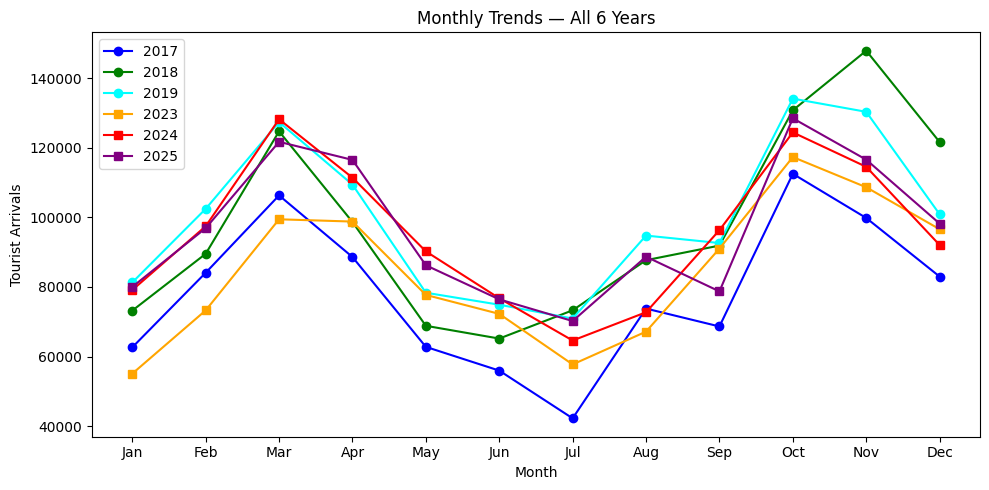

In [77]:
plt.figure(figsize=(10, 5))
plt.plot(months, y2017, marker='o', label='2017', color='blue')
plt.plot(months, y2018, marker='o', label='2018', color='green')
plt.plot(months, y2019, marker='o', label='2019', color='cyan')
plt.plot(months, y2023, marker='s', label='2023', color='orange')
plt.plot(months, y2024, marker='s', label='2024', color='red')
plt.plot(months, y2025, marker='s', label='2025', color='purple')
plt.title('Monthly Trends — All 6 Years')
plt.xlabel('Month')
plt.ylabel('Tourist Arrivals')
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion ::
The line chart shows all 6 years follow the same seasonal pattern peaking in March and October/November and dropping lowest in July. The Pre-COVID years (2017–2019) and Post-COVID years (2023–2025) lines closely overlap each other, confirming that Nepal's tourism has fully recovered. COVID temporarily destroyed tourist numbers but did not change the seasonal pattern at all.

2) Bar Chart with CI

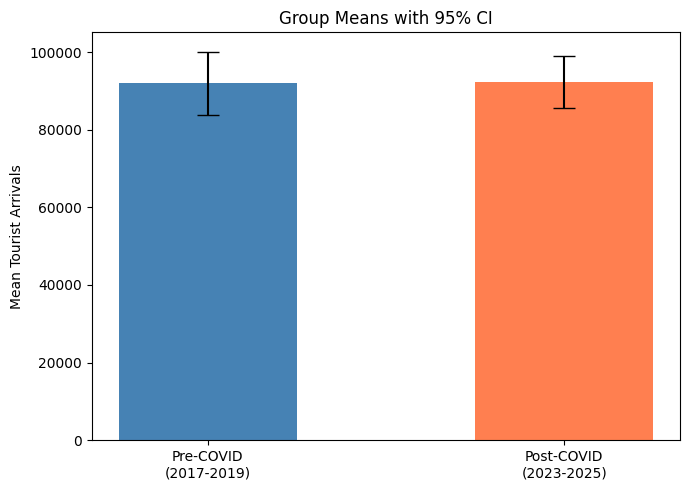

In [83]:
plt.figure(figsize=(7, 5))
se_g1 = std_g1 / np.sqrt(len(g1))
se_g2 = std_g2 / np.sqrt(len(g2))
ci_g1 = 1.96 * se_g1
ci_g2 = 1.96 * se_g2
bars = plt.bar(['Pre-COVID\n(2017-2019)', 'Post-COVID\n(2023-2025)'],
               [mean_g1, mean_g2],
               yerr=[ci_g1, ci_g2],
               color=['steelblue', 'coral'],
               capsize=8, width=0.5)
plt.title('Group Means with 95% CI')
plt.ylabel('Mean Tourist Arrivals')
plt.tight_layout()
plt.show()

## Conclusion
The bar chart shows that Pre-COVID mean (91,958) and Post-COVID mean (92,247) are almost identical in height. The 95% confidence intervals overlap significantly, meaning the difference between the two groups is not statistically significant. This visually confirms our Z-test result — we fail to reject H0 — Nepal's average monthly tourist arrivals have fully recovered to Pre-COVID levels.

3) Histogram

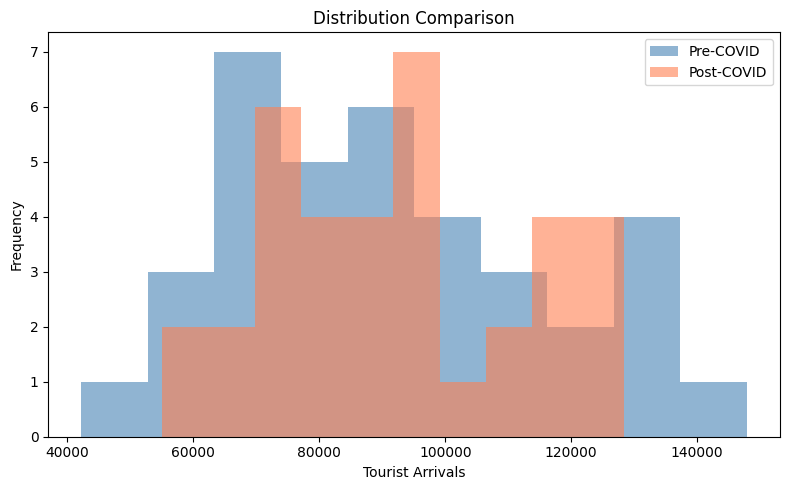

In [79]:
plt.figure(figsize=(8, 5))
plt.hist(g1, bins=10, alpha=0.6, color='steelblue', label='Pre-COVID')
plt.hist(g2, bins=10, alpha=0.6, color='coral', label='Post-COVID')
plt.title('Distribution Comparison')
plt.xlabel('Tourist Arrivals')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

### Conclusion::
The histogram shows both Pre-COVID and Post-COVID distributions are centered around the same range (70,000–100,000), confirming similar average arrivals. The Post-COVID distribution (orange) is slightly more concentrated with less spread, while Pre-COVID (blue) is more spread out reaching up to 150,000. Both distributions overlap heavily in the middle range, visually supporting our conclusion that there is no significant difference between the two groups.

4) Scatter Plots

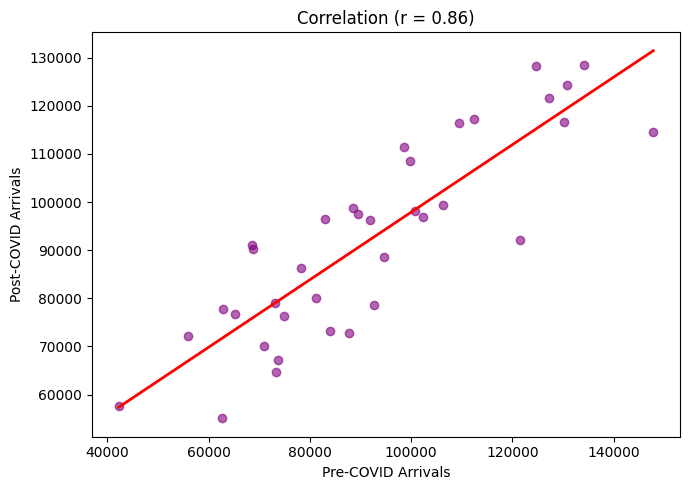

In [80]:
plt.figure(figsize=(7, 5))
plt.scatter(g1, g2, color='purple', alpha=0.6)
m, b = np.polyfit(g1, g2, 1)
x_line = np.linspace(g1.min(), g1.max(), 100)
plt.plot(x_line, m * x_line + b, color='red', linewidth=2)
plt.title(f'Correlation (r = {round(corr_g2g1, 4)})')
plt.xlabel('Pre-COVID Arrivals')
plt.ylabel('Post-COVID Arrivals')
plt.tight_layout()
plt.show()

### Conclusion::
The scatter plot shows a strong positive correlation (r = 0.86) between Pre-COVID and Post-COVID monthly tourist arrivals. The data points follow the red regression line closely, meaning when Pre-COVID arrivals were high, Post-COVID arrivals were also high in the same months. This confirms that Nepal's seasonal tourism pattern remained consistent before and after COVID.